In [35]:
import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [36]:
import zipfile

zip_path = "/content/Plant_Disease_Workshop (1).zip"

extract_path = "/content"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully")

Dataset extracted successfully


In [37]:
dataset_path ="/content/Plant_Disease_Workshop/train"
print(os.listdir(dataset_path))

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [38]:
dataset_path ="/content/Plant_Disease_Workshop/val"
print(os.listdir(dataset_path))

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [39]:
train_path = "/content/Plant_Disease_Workshop/train"
val_path = "/content/Plant_Disease_Workshop/val"
print("======== TRSIN DATA ======== \n")

for folder in os.listdir(train_path):
  folder_path = os.path.join(train_path, folder)
  print(folder, ":", len(os.listdir(folder_path)), "images")

print("======== VALIDATION DATA ======== \n")

for folder in os.listdir(val_path):
  folder_path = os.path.join(val_path, folder)
  print(folder, ":", len(os.listdir(folder_path)), "images")

======== TRSIN DATA ======== 

Potato___Early_blight : 800 images
Potato___Late_blight : 800 images
Potato___healthy : 121 images
======== VALIDATION DATA ======== 

Potato___Early_blight : 200 images
Potato___Late_blight : 200 images
Potato___healthy : 31 images


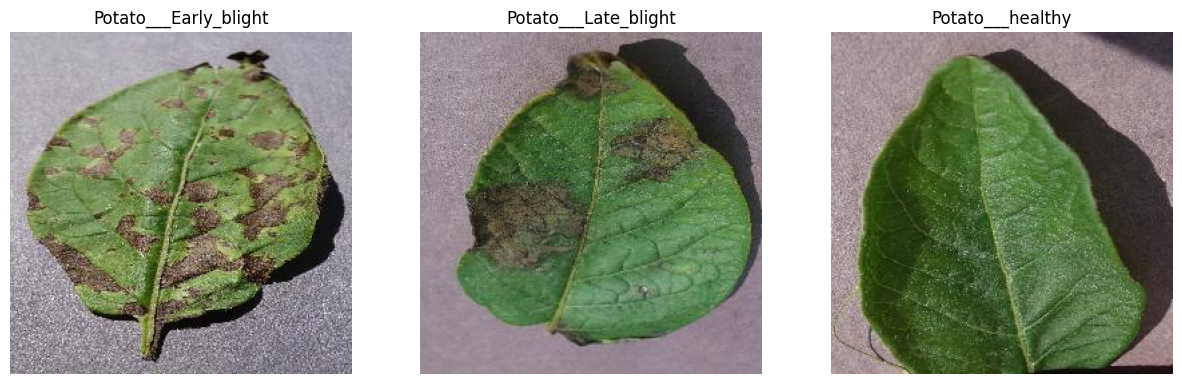

In [40]:
plt.figure(figsize=(15, 5))
classes = os.listdir(train_path)
for i, folder in enumerate(classes):
  image_name = os.listdir(os.path.join(train_path, folder))[0]
  image_path = os.path.join(train_path, folder, image_name)
  image = cv2.imread(image_path)
  image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
  plt.subplot(1,3,i+1)
  plt.imshow(image)
  plt.title(folder)
  plt.axis("off")
plt.show()

In [41]:
train_path = "/content/Plant_Disease_Workshop/train"
val_path = "/content/Plant_Disease_Workshop/val"
image_size = (64,64)

In [42]:
X_train = []
y_train = []

X_val = []
y_val = []

In [43]:
for label in os.listdir(train_path):
  folder_path = os.path.join(train_path, label)
  for image_name in os.listdir(folder_path):
    image_path = os.path.join(folder_path, image_name)
    image = cv2.imread(image_path)
    image = cv2.resize(image, image_size)
    X_train.append(image)
    y_train.append(label)
print("Train data loaded successfully!")

Train data loaded successfully!


In [44]:
for label in os.listdir(val_path):
  folder_path = os.path.join(val_path, label)
  for image_name in os.listdir(folder_path):
    image_path = os.path.join(folder_path, image_name)
    image = cv2.imread(image_path)
    image = cv2.resize(image, image_size)
    X_val.append(image)
    y_val.append(label)
print("Val data loaded successfully!")

Val data loaded successfully!


In [45]:
print("Training Images :", len(X_train))
print("Training Labels :", len(y_train))

print()

print("Validation Images :", len(X_val))
print("Validation Laels :", len(y_val))


Training Images : 1721
Training Labels : 1721

Validation Images : 431
Validation Laels : 431


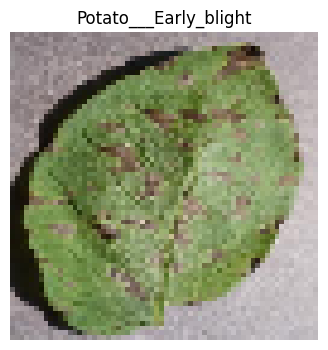

In [46]:
plt.figure(figsize=(4,4))
plt.imshow(cv2.cvtColor(X_train[2], cv2.COLOR_BGR2RGB))
plt.title(y_train[2])
plt.axis("off")
plt.show()

In [47]:
X_train = np.array(X_train)
X_val = np.array(X_val)

y_train = np.array(y_train)
y_val = np.array(y_val)

print("Converted Successfully!")

Converted Successfully!


In [48]:
print("Training Shape :", X_train.shape)
print("Validation Shape :", y_val.shape)

Training Shape : (1721, 64, 64, 3)
Validation Shape : (431,)


In [49]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_val = X_val.reshape(X_val.shape[0], -1)

print("Images flattened successfully")

Images flattened successfully


In [50]:
print("Training Shape :", X_train.shape)
print("Validation Shape :", y_val.shape)

Training Shape : (1721, 12288)
Validation Shape : (431,)


In [51]:
X_train = X_train/255.0
X_val = X_val/255.0

print("Normalization Complited")

Normalization Complited


In [52]:
encoder = LabelEncoder()

y_train = encoder.fit_transform(y_train)
y_val= encoder.transform(y_val)

print("Labels Encoder Successfully")

Labels Encoder Successfully


In [53]:
print("Encoded Classes:")
print(encoder.classes_)

print()

print("First 10 Labels:")
print(y_train[:10])

Encoded Classes:
['Potato___Early_blight' 'Potato___Late_blight' 'Potato___healthy']

First 10 Labels:
[0 0 0 0 0 0 0 0 0 0]


In [54]:
print("Training Features shape :", X_train.shape)
print("Training labels shape :", X_val.shape)

print()

print("Validation Features shape :", X_train.shape)
print("Validation labels shape :", X_val.shape)

Training Features shape : (1721, 12288)
Training labels shape : (431, 12288)

Validation Features shape : (1721, 12288)
Validation labels shape : (431, 12288)


In [55]:
loistic_model = LogisticRegression(max_iter=1000)

print("Logistic Regression Model created successfully")

Logistic Regression Model created successfully


In [83]:
loistic_model.fit(X_train,y_train)
print("model training completed")

model training completed


In [57]:
y_pred =loistic_model.predict(X_val)

print("Prediction completed")

Prediction completed


In [58]:
print("Actual Labels  :", y_val[:10])
print("predicted Labels  :", y_pred[:10])



Actual Labels  : [0 0 0 0 0 0 0 0 0 0]
predicted Labels  : [0 0 0 0 0 0 0 0 0 0]


In [59]:
acc = accuracy_score(y_val, y_pred)
print("Accuracy score is :", round(acc * 100,2),"%")

Accuracy score is : 90.72 %


In [60]:
cmx = confusion_matrix(y_val, y_pred)
print(cmx)

[[185  15   0]
 [  8 189   3]
 [  0  14  17]]


In [61]:
print(classification_report(y_val, y_pred,target_names=encoder.classes_))

                       precision    recall  f1-score   support

Potato___Early_blight       0.96      0.93      0.94       200
 Potato___Late_blight       0.87      0.94      0.90       200
     Potato___healthy       0.85      0.55      0.67        31

             accuracy                           0.91       431
            macro avg       0.89      0.81      0.84       431
         weighted avg       0.91      0.91      0.90       431



In [62]:
predict_labels = encoder.inverse_transform(y_pred[:10])

print("First 10 predicted Disease,Names:")
print(predict_labels)

First 10 predicted Disease,Names:
['Potato___Early_blight' 'Potato___Early_blight' 'Potato___Early_blight'
 'Potato___Early_blight' 'Potato___Early_blight' 'Potato___Early_blight'
 'Potato___Early_blight' 'Potato___Early_blight' 'Potato___Early_blight'
 'Potato___Early_blight']


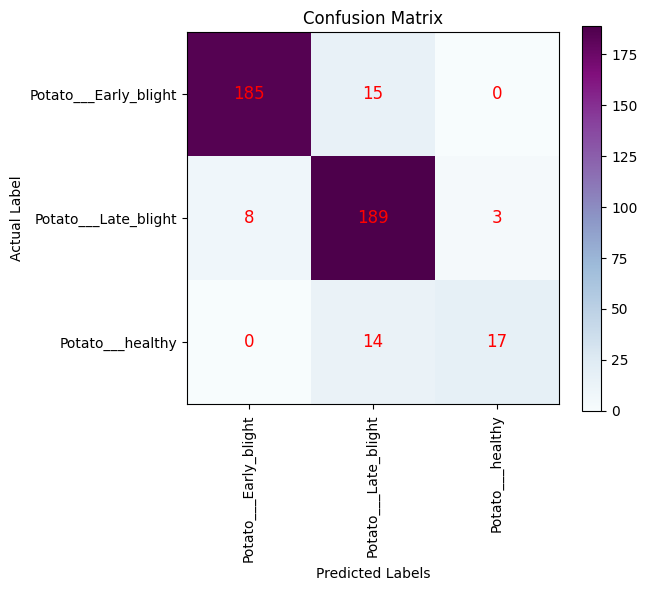

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(cmx, cmap="BuPu")
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(3), encoder.classes_, rotation=90)
plt.yticks(range(3), encoder.classes_)

for i in range(len(cmx)):
  for j in range(len(cmx)):
    plt.text(j, i, cmx[i,j], ha="center", va="center", color="red", fontsize=12)

plt.xlabel("Predicted Labels")
plt.ylabel("Actual Label")
plt.show()

In [64]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_val, y_pred)

print("=" * 40)
print("Logistic Regression Completed Successfully")
print("=" * 40)

print(f"Accuracy : {accuracy * 100:.2f}%")

Logistic Regression Completed Successfully
Accuracy : 90.72%


In [65]:
svm_model = SVC(kernel="linear")

print("Support Vector Machine model created successfully!")

Support Vector Machine model created successfully!


In [66]:
svm_model.fit(X_train,y_train)

print("Model Training Completed Successfully")

Model Training Completed Successfully


In [67]:
print("Accuracy score is :", round(acc * 100,2),"%")

Accuracy score is : 90.72 %


In [68]:
y_pred = svm_model.predict(X_val)
print("Prediction completed")

Prediction completed


In [84]:
svm_acc = accuracy_score(y_val, y_pred)
print("Accuracy score :", round(svm_acc * 100,2),"%")

Accuracy score : 91.18 %


In [86]:
svm_cmx = confusion_matrix(y_val,y_pred)
print(svm_cmx)

[[183  17   0]
 [  9 188   3]
 [  1   8  22]]


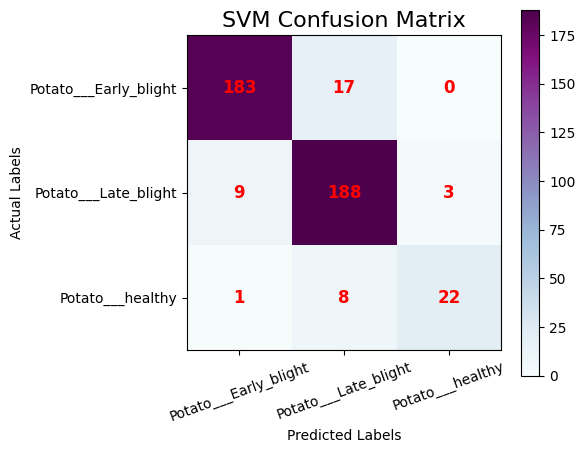

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.imshow(svm_cmx,cmap="BuPu")

plt.title("SVM Confusion Matrix", fontsize=16)
plt.colorbar()

plt.xticks(range(len(encoder.classes_)), encoder.classes_, rotation=20)
plt.yticks(range(len(encoder.classes_)), encoder.classes_)

for i in range(svm_cmx.shape[0]):
    for j in range(svm_cmx.shape[1]):
        plt.text(
            j, i, svm_cmx[i, j],
            ha="center",
            va="center",
            color="red",
            fontsize=12,
            fontweight="bold"
        )

plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.tight_layout()
plt.show()

In [72]:
from google.colab import files

uploded = files.upload()

Saving lif.jpg to lif (1).jpg


Saving lif.jpg to lif (2).jpg


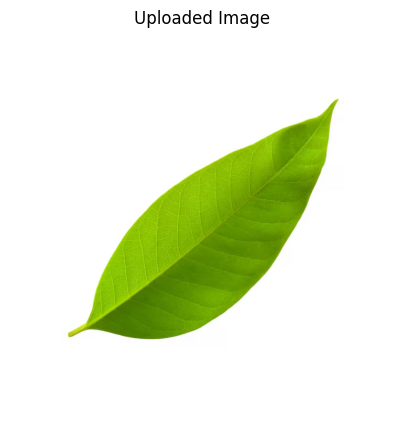

In [73]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

Uploaded = files.upload()

image_name = list(Uploaded.keys())[0]

image = cv2.imread(image_name)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(image_rgb)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

In [74]:
test_image = cv2.resize(image, (64, 64))
test_image = test_image.reshape(1, -1)
test_image = test_image/255.0
print("Image Preprocessed Successfully")

Image Preprocessed Successfully


In [75]:
prediction = svm_model.predict(test_image)
predicted_disease = encoder.inverse_transform(prediction)
print("Predicted Disease :", predicted_disease[0])

Predicted Disease : Potato___Early_blight


In [76]:
if predicted_disease[0] == "Potato___Early_blight":
  print("Disease: Early Blight")
  print("Advice: Remove infected leaves and apply a suitable fungicide.")
elif predicted_disease[0] == "Potato___Late_blight":
  print("Disease: Late Blight")
  print("Advice: Improve drainage, avoid overhead watering, and use recommand.")

else:
  print("Disease: Healthy Leaf")
  print("Advice: No disease detected. Counting regular crop care.")

Disease: Early Blight
Advice: Remove infected leaves and apply a suitable fungicide.


In [88]:
comparison = {
    "Model":["Logistic Regression", "Support Vector Machine"],
    "Accuracy":[acc * 100, svm_acc *100]
}

import pandas as pd
comparison_df = pd.DataFrame(comparison)
comparison_df

,Model,Accuracy
0,Logistic Regression,91.183295
1,Support Vector Machine,91.183295


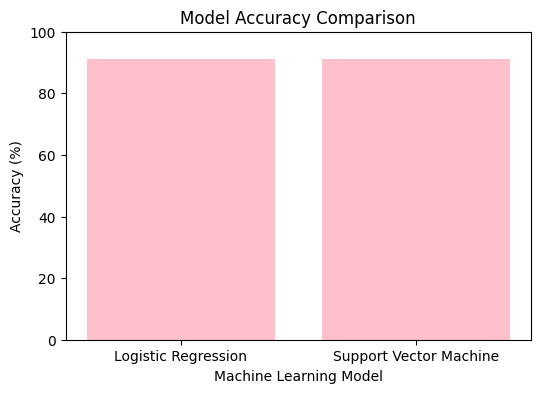

In [89]:
plt.figure(figsize=(6,4))
plt.bar(comparison_df["Model"], comparison_df["Accuracy"],color="pink")
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0,100)
plt.show()

In [90]:
if svm_acc > acc:
  print("Best Model: Support Vector Machine")
else:
  print("Best Model: Logistic Regression")

Best Model: Logistic Regression
